In [1]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(scales)
library(patchwork)

Warning message:
“程辑包‘dplyr’是用R版本4.2.3 来建造的”

载入程辑包：‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“程辑包‘tidyr’是用R版本4.2.3 来建造的”


In [3]:
# 读入你刚刚导出的统计表
stat_df <- read.csv(
      "/sibcb1/bioinformatics/yangyue/project/immunotherapy/7.3.cNMF_NK/4.3.2.NK_usage_immu_pheatmap/4.3.2.NK_cGEP_usage_cell_patient_stats.csv",
  stringsAsFactors = FALSE
)
stat_df

dataset,cGEP,cell_N_R,cell_N_NR,cell_median_R,cell_median_NR,cell_pvalue,cell_auc,patient_N_R,patient_N_NR,patient_median_R,patient_median_NR,patient_pvalue,patient_auc
<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
GSE123813_BCC,cGEP1,511,530,1.082787e-02,6.640469e-03,1.888195e-04,0.5668537,4,9,2.649705e-02,2.410642e-02,0.93986014,0.5277778
GSE123813_BCC,cGEP2,511,530,6.138917e-05,6.860106e-06,6.915622e-32,0.7104272,4,9,3.458767e-04,2.145231e-04,0.33006993,0.6944444
GSE123813_BCC,cGEP3,511,530,6.412782e-02,1.470519e-02,5.259156e-56,0.7823210,4,9,5.749457e-02,3.987389e-02,0.41398601,0.6666667
GSE123813_BCC,cGEP4,511,530,2.430434e-01,2.378890e-01,2.591169e-01,0.5202082,4,9,2.550041e-01,2.573716e-01,0.82517483,0.4444444
GSE123813_BCC,cGEP5,511,530,1.098530e-02,2.050393e-04,1.089748e-52,0.7735480,4,9,8.404631e-03,7.852246e-03,0.93986014,0.4722222
GSE123813_BCC,cGEP6,511,530,1.782799e-03,2.450954e-02,2.486627e-59,0.7908540,4,9,1.524942e-02,2.301437e-02,0.50349650,0.6388889
GSE123813_BCC,cGEP7,511,530,8.846045e-07,5.614736e-08,1.144959e-14,0.6382712,4,9,4.843720e-05,3.180796e-04,0.26013986,0.7222222
GSE123813_BCC,cGEP8,511,530,5.592650e-02,1.703586e-02,1.383519e-56,0.7838275,4,9,4.913594e-02,2.546533e-02,0.07552448,0.8333333
GSE123813_BCC,cGEP9,511,530,1.201688e-01,1.971285e-01,1.023230e-29,0.7027286,4,9,1.465151e-01,1.963931e-01,0.50349650,0.6388889


In [4]:
# 先画病人的汇总热图。
# 只保留有 patient_auc 的
heat_df <- stat_df %>%
  select(dataset, cGEP, patient_N_R, patient_N_NR, patient_auc) %>%
  filter(!is.na(patient_auc))
colnames(heat_df)[2] = 'pathway'
colnames(heat_df)[3] = 'patient_R'
colnames(heat_df)[4] = 'patient_NR'

In [5]:
# 排序
# 1.dataset 按名字
heat_df$dataset <- factor(
  heat_df$dataset,
  levels = unique(heat_df$dataset))

# 2. pathway , 1 到 41 的正确名称列表
levels_order <- paste0("cGEP", 1:41)

# 将 pathway 转换为因子，并指定 levels 顺序
heat_df$pathway <- factor(heat_df$pathway, levels = levels_order)
heat_df

dataset,pathway,patient_R,patient_NR,patient_auc
<fct>,<fct>,<int>,<int>,<dbl>
GSE123813_BCC,cGEP1,4,9,0.5277778
GSE123813_BCC,cGEP2,4,9,0.6944444
GSE123813_BCC,cGEP3,4,9,0.6666667
GSE123813_BCC,cGEP4,4,9,0.4444444
GSE123813_BCC,cGEP5,4,9,0.4722222
GSE123813_BCC,cGEP6,4,9,0.6388889
GSE123813_BCC,cGEP7,4,9,0.7222222
GSE123813_BCC,cGEP8,4,9,0.8333333
GSE123813_BCC,cGEP9,4,9,0.6388889


In [6]:
# --- 1. 数据过滤与准备 ---
# 过滤掉不需要的数据集
exclude_datasets <- c("RenalCarcinoma","HCC_YeYouqiong")
heat_df_filt <- heat_df[!(heat_df$dataset %in% exclude_datasets), ]
heat_df_filt

,dataset,pathway,patient_R,patient_NR,patient_auc
,<fct>,<fct>,<int>,<int>,<dbl>
1,GSE123813_BCC,cGEP1,4,9,0.5277778
2,GSE123813_BCC,cGEP2,4,9,0.6944444
3,GSE123813_BCC,cGEP3,4,9,0.6666667
4,GSE123813_BCC,cGEP4,4,9,0.4444444
5,GSE123813_BCC,cGEP5,4,9,0.4722222
6,GSE123813_BCC,cGEP6,4,9,0.6388889
7,GSE123813_BCC,cGEP7,4,9,0.7222222
8,GSE123813_BCC,cGEP8,4,9,0.8333333
9,GSE123813_BCC,cGEP9,4,9,0.6388889


In [7]:
library(dplyr)
immudataInfo <- read.csv(
      "/sibcb1/bioinformatics/yangyue/project/immunotherapy/7.2.cNMF_CD8T/4.3.2.CD8T_usage_immu_pheatmap/4.2.免疫治疗dataset.csv",
  stringsAsFactors = FALSE)

# 1. 预处理 immudataInfo，生成对应的标签格式
# 格式为：Cancer_Dataset(Treatment)
info_mapping <- immudataInfo %>%
  mutate(new_label = paste0(Cancer, "_", Dataset, "(", Treatment, ")")) %>%
  select(Dataset, new_label)

# 2. 将新标签合并到 heat_df_filt 中
# 使用 left_join 根据 Dataset 进行匹配
heat_df_filt2 <- heat_df_filt %>%
  left_join(info_mapping, by = c("dataset" = "Dataset")) %>%
  mutate(dataset = ifelse(!is.na(new_label), new_label, dataset)) %>%
  select(-new_label) # 移除临时列


In [8]:
NK_cGEP <- read.csv("/sibcb1/bioinformatics/yangyue/project/immunotherapy/7.3.cNMF_NK/3.3.NK_cGEP_ALL_ANNO/3.3.NK_cGEP_Anno_Complete_With_Genes_final.csv",
  stringsAsFactors = FALSE,
  check.names = FALSE)
NK_cGEP$cGEP_Cluster <- factor(NK_cGEP$cGEP_Cluster, levels = paste0("cGEP", 1:41))
NK_cGEP$Display_Label <- paste0(NK_cGEP$cGEP_Cluster, ": ", NK_cGEP$cGEP_Anno_Name)
NK_cGEP <- NK_cGEP[order(NK_cGEP$cGEP_Cluster), ]
NK_cGEP

,cGEP_Cluster,cGEP_Anno_Name,Category,cGEP_signature,Display_Label
,<fct>,<chr>,<chr>,<chr>,<chr>
1,cGEP1,Low_Quality_Mito,Artifact,"CYTB,COX2,ATP6,ND4L,COX3,ND1,EIF1,ND5,6h.2,ATP8,H3F3B,AC107241.1,HLA-H,4h.2,C20orf24,PTMA,0h.1,FTH1,24h.2,ND4,LITAF,RBM39,SRSF5,ND2,DNAJB6,TMEM56,CEMIP2,RPS14P3,PDE4D,ND3",cGEP1: Low_Quality_Mito
2,cGEP2,TaNK_Cytoskeleton_Stress,Functional,"PFN1,ACTB,FCER1G,HSPA1A,IFITM1,TMSB10,MYL12A,NKG7,SERF2,TMSB4X,GSTP1,ND3,PPIA,ATP5E,IFITM2,ALOX5AP,AC245427.1,CFL1,TYROBP,ATP5F1E,HSPA1B,DNAJB1,MTRNR2L2,CLIC1,ATP5MF,MIF,HCST,B2M,RAC2,RPL39",cGEP2: TaNK_Cytoskeleton_Stress
3,cGEP3,Translational_Activity,Functional,"RPS12,RPS2,RPS3,RPS27,RPS18,RPS15A,RPS14,EEF1A1,RPL13,RPL3,RPS4X,RPS28,RPL32,RP11-761N21.2,RP11-864N7.2,RPL34,RPL10,RPL23A,RPS23,RPL18A,RPS6,RPL19,RPS27A,RPL26,RPS8,PLAAT4,RPL30,RPS19,RPS29,RPL11",cGEP3: Translational_Activity
4,cGEP4,TaNK_HSP_Stress,Functional,"DNAJB1,HSPA1A,HSP90AA1,HSPE1,HSPA1B,HSPH1,HSPD1,BAG3,HSPA6,CACYBP,ZFAND2A,HSPA8,COL21A1,HSP90AB1,HSPB1,HSP90AA2P,DNAJA1,SERPINH1,PPP1R15A,UBC,NR4A1,ATF3,FKBP4,DNAJB4,MRPL18,JUN,DOK2,TFF1,TNFSF14,DEDD2",cGEP4: TaNK_HSP_Stress
5,cGEP5,NK_Activation_IEG,Functional,"ZFP36,BTG2,NR4A2,JUNB,NR4A1,CD69,TNFAIP3,LOC284454,CXCR4,FOSB,RP11-463O12.5,NFKBIA,MCL1,JUN,PPP1R15A,AREG,IER2,DUSP2,NFKBIZ,ZNF331,FOS,AC027290.2,KDM6B,TSC22D3,REL,CSRNP1,DNAJA1,DUSP1,EGR1,NR4A3",cGEP5: NK_Activation_IEG
6,cGEP6,Acute_Inflammatory,Functional,"IGFBP1,ITIH3,AL158850.1,MT-ND4,MT-CO3,MT-CO2,MT-CYB,MT-ATP6,MT-ND1,MT-ND3,MT-ND2,LBP,MT-CO1,RHEX,PNCK,MT-ND5,FGL1,FGA,ORM1,IGHV4-34,MT-ND4L,APOB,AL445673.1,NTM,CRP,PLA2G2A,SAA1,ROR1,UGT2B7,F2",cGEP6: Acute_Inflammatory
7,cGEP7,trNK_Quiescence,Lineage,"BTG1,ITM2C,RPL13A,KRT81,RPS20,CAPG,RPS26,GZMK,RPL27A,KRT86,MALAT1,RPS2,CXCR6,CD44,RPS29,RPL37A,TXNIP,CXCR4,LINC00996,CD9,APOBEC3G,PNRC1,SLFN5,CXCR3,VIM,EPHA1,AC026366.1,RPLP2,RPL10A,SRGAP3",cGEP7: trNK_Quiescence
8,cGEP8,CD56bright_Translation,Lineage,"RPS12,RPL13,RPLP1,TPT1,IL7R,CCR6,RPL32,NCR2,RPL30,EEF1A1,RPL10,RPS23,APOC4-APOC2,AL445686.2,RPL28,GPR183,RPL34,RPS8,RPL8,RPLP0,VIM,AMICA1,RPS18,U62317.3,RPS14,RPL11,RPL41,RPS5,RPS13,RPS25",cGEP8: CD56bright_Translation
9,cGEP9,CD56dim_Cytotoxic,Lineage,"NKG7,PRF1,SPON2,FGFBP2,GZMB,FCGR3A,SCGB1D2,B2M,ITGB2,CST7,PFN1,GZMA,ACTB,IGFBP7,GPR56,CX3CR1,CYBA,CFL1,AKR1C3,TMSB10,FCER1G,CD247,MT-COX1,PRSS23,MYL12A,LOC101060789,PLAC8,S100A4,EMP3,GZMH",cGEP9: CD56dim_Cytotoxic


In [9]:
library(dplyr)
library(ggplot2)
library(patchwork)

# =========================================================
# 函数：绘制 NK_cGEP cGEP 热图 + 可选注释条过滤
# =========================================================
plot_NK_heatmap <- function(
  heat_df,           # 主热图数据框，列：dataset, pathway, patient_auc
  anno_df,           # 注释数据框，列：cGEP_Cluster, cGEP_Anno_Name, Category
  keep_categories,   # 需要保留的 Category 向量，例如 c("Function","Artifact")
  output_file,       # 保存 PDF 路径
  width = 12,
  height = 16,
  fill_midpoint = 0.6
) {
  
  # ---------------------------
  # 1️⃣ 排序 cGEP
  # ---------------------------
  sorted_cgeps <- heat_df %>%
    group_by(pathway) %>%
    summarise(mean_auc = mean(patient_auc, na.rm = TRUE)) %>%
    arrange(mean_auc) %>%
    pull(pathway)
  
  # ---------------------------
  # 2️⃣ 主热图 factor
  # ---------------------------
  heat_df$pathway <- factor(heat_df$pathway, levels = sorted_cgeps)
  
  # ---------------------------
  # 3️⃣ 注释条 factor & 过滤
  # ---------------------------
  # 关键修改：只保留热图中存在的cGEP_Cluster
  anno_df <- anno_df %>%
    filter(cGEP_Cluster %in% sorted_cgeps) %>%  # 先过滤热图中存在的Cluster
    filter(Category %in% keep_categories) %>%   # 再过滤需要的类别
    arrange(match(cGEP_Cluster, sorted_cgeps))  # 按照热图顺序排序
  
  # 更新sorted_cgeps，只包含注释条中存在的
  sorted_cgeps_filtered <- intersect(sorted_cgeps, unique(anno_df$cGEP_Cluster))
  
  # 设置因子水平（使用过滤后的顺序）
  anno_df$cGEP_Cluster <- factor(anno_df$cGEP_Cluster, levels = sorted_cgeps_filtered)
  
  # labels 对齐
  anno_labels <- anno_df$cGEP_Anno_Name
  names(anno_labels) <- anno_df$cGEP_Cluster
  
  # ---------------------------
  # 4️⃣ 主热图（需要过滤以匹配注释条）
  # ---------------------------
  # 如果注释条过滤后为空，则不绘制注释条
  if (nrow(anno_df) == 0) {
    warning("过滤后注释条为空，将只绘制热图")
    heat_df_filtered <- heat_df
  } else {
    # 只保留注释条中存在的pathway
    heat_df_filtered <- heat_df %>%
      filter(pathway %in% sorted_cgeps_filtered)
    
    # 重新设置因子水平以匹配注释条顺序
    heat_df_filtered$pathway <- factor(heat_df_filtered$pathway, levels = sorted_cgeps_filtered)
  }
  
  p_main <- ggplot(
    heat_df_filtered,
    aes(x = dataset, y = pathway, fill = patient_auc)
  ) +
    geom_tile(color = "white", linewidth = 0.2) +
    scale_fill_gradient2(
      low = "#2166AC", mid = "white", high = "#B2182B",
      midpoint = fill_midpoint, name = "AUC"
    ) +
    scale_x_discrete(expand = c(0, 0)) +
    scale_y_discrete(expand = c(0, 0)) +
    theme_minimal() +
    theme(
      axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1, size = 10, color = "black", face = "bold"), # 【修改】X轴加粗
      axis.text.y = element_text(size = 8, color = "black", face = "bold"),                                    # 【修改】Y轴加粗
      panel.grid = element_blank(),
      axis.title = element_blank(),
      legend.position = "left",
      plot.margin = margin(t = 10, r = 0, b = 60, l = 30, unit = "pt")
    )
  
  # ---------------------------
  # 5️⃣ 注释条（仅在存在数据时绘制）
  # ---------------------------
  if (nrow(anno_df) > 0) {
    fill_values <- setNames(
      c("#4daf4a", "#999999", "#377eb8", "#984ea3")[match(keep_categories, c("Functional","Artifact","Lineage","Doublet"))],
      keep_categories
    )
    
    p_side <- ggplot(
      anno_df,
      aes(x = "Class", y = cGEP_Cluster, fill = Category)
    ) +
      geom_tile(color = "white", linewidth = 0.2) +
      scale_fill_manual(values = fill_values, name = "Class") +
      scale_x_discrete(expand = c(0, 0)) +
      scale_y_discrete(
        expand = c(0, 0), 
        position = "right", 
        labels = anno_labels,
        limits = levels(anno_df$cGEP_Cluster)  # 确保与热图y轴完全一致
      ) +
      theme_minimal() +
      theme(
        axis.text.x = element_text(angle = 90, vjust = 0.5, size = 10, face = "bold", color = "black"), # 【修改】X轴统一使用 bold
        axis.text.y = element_text(size = 8, color = "black", face = "bold"),                           # 【修改】Y轴加粗
        panel.grid = element_blank(),
        axis.title = element_blank(),
        plot.margin = margin(t = 10, r = 100, b = 60, l = 0, unit = "pt")
      )
    
    # ---------------------------
    # 6️⃣ 拼接 + 保存
    # ---------------------------
    final_plot <- (p_main | p_side) +
      plot_layout(widths = c(5, 0.3), guides = "collect") &
      theme(
        panel.spacing = unit(0, "pt"),
        legend.text = element_text(face = "bold"),   # 【修改】图例文字加粗
        legend.title = element_text(face = "bold")   # 【修改】图例标题加粗
      )
  } else {
    # 如果注释条为空，只绘制热图
    final_plot <- p_main +
      theme(
        legend.text = element_text(face = "bold"),   # 【修改】单独热图的图例也加粗
        legend.title = element_text(face = "bold")
      )
  }
  
  ggsave(output_file, final_plot, width = width, height = height, limitsize = FALSE)
  
  return(final_plot)
}

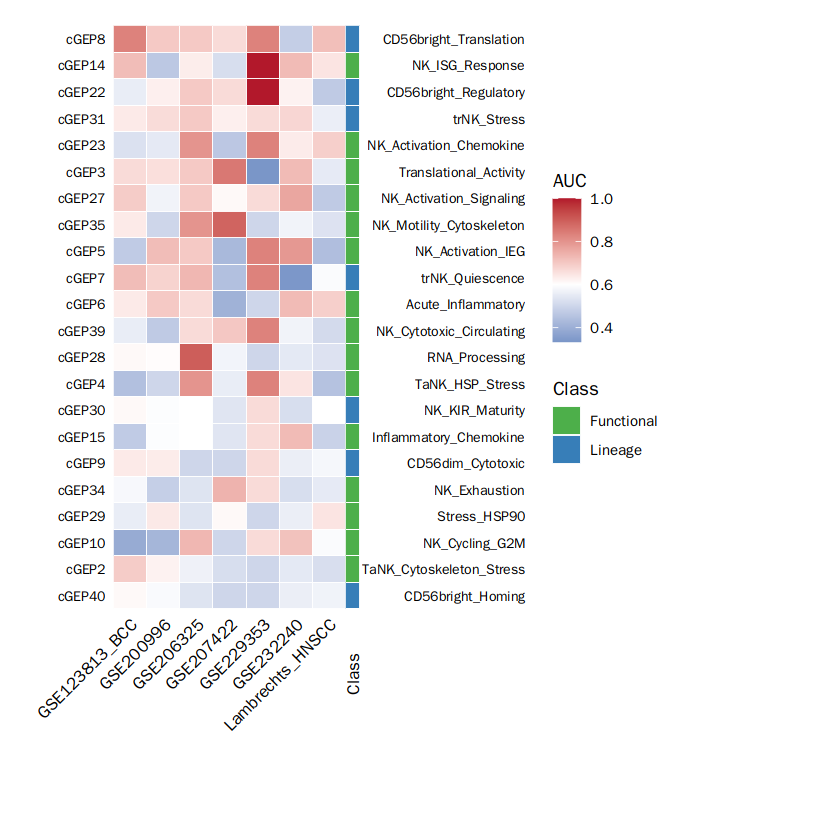

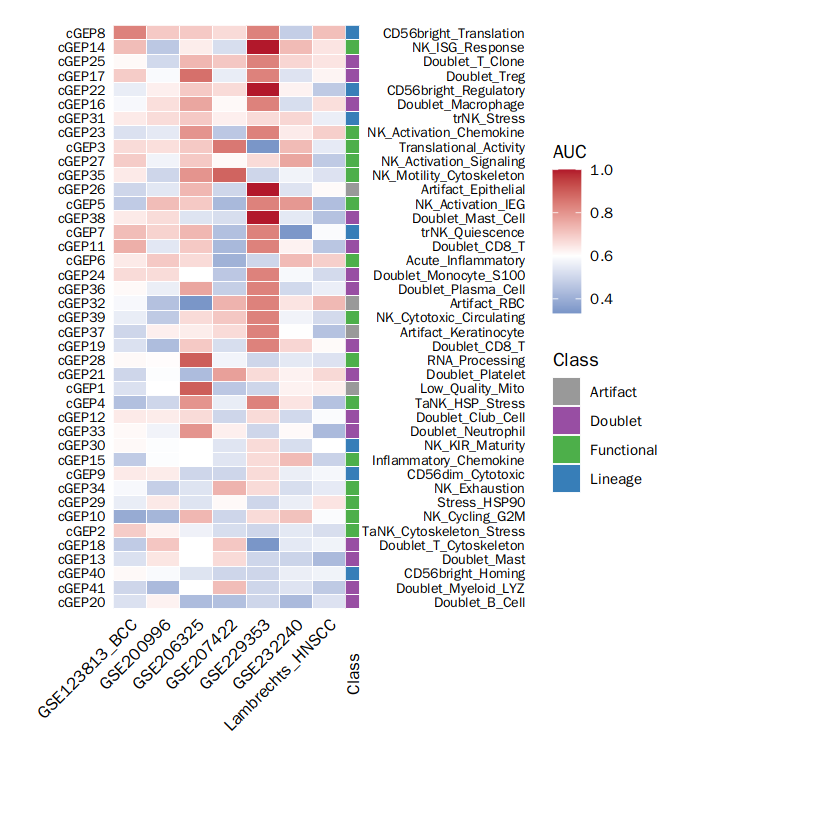

In [10]:
# 只保留 Function 和 Artifact
plot_NK_heatmap(
  heat_df = heat_df_filt,
  anno_df = NK_cGEP,
  keep_categories = c("Functional","Lineage"),
  output_file = "./4.3.2.NK_usage_immu_pheatmap/4.3.2.NK_GEP41_usage_heatmap_filtered_sorted_mean.pdf",
  width = 12,
  height = 16
)

# 都留
plot_NK_heatmap(
  heat_df = heat_df_filt,
  anno_df = NK_cGEP,
  keep_categories = c("Functional","Artifact","Lineage","Doublet"),
  output_file = "./4.3.2.NK_usage_immu_pheatmap/4.3.2.NK_GEP41_usage_heatmap_all_sorted_mean.pdf",
  width = 12,
  height = 16
)


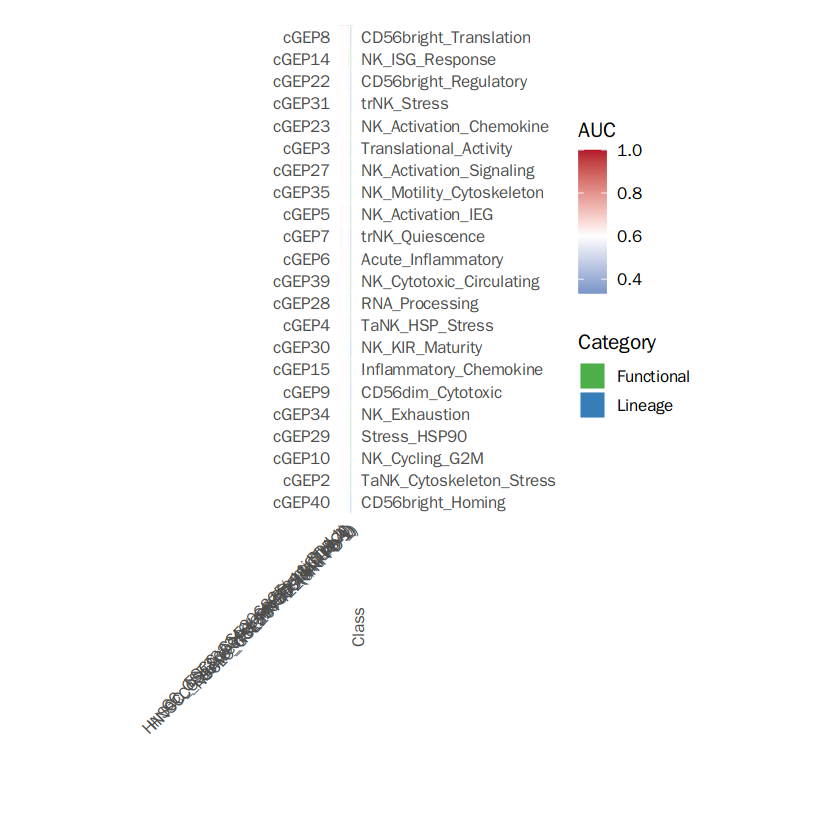

In [ ]:
library(dplyr)
library(ggplot2)
library(patchwork)

plot_heatmap <- function(
  heat_df,
  anno_df,
  keep_categories,
  output_file,
  cell_width = 0.5,
  cell_height = 0.25,
  fill_midpoint = 0.6
){

  # 1️⃣ 排序 pathway
  sorted_cgeps <- heat_df %>%
    group_by(pathway) %>%
    summarise(mean_auc = mean(patient_auc, na.rm = TRUE)) %>%
    arrange(mean_auc) %>%
    pull(pathway)

  heat_df$pathway <- factor(heat_df$pathway, levels = sorted_cgeps)

  # 2️⃣ annotation 过滤
  anno_df <- anno_df %>%
    filter(Category %in% keep_categories)

  # 保证 annotation 与 heatmap 完全一致
  anno_df <- anno_df %>%
    filter(cGEP_Cluster %in% sorted_cgeps)

  # 按热图顺序排序
  anno_df <- anno_df %>%
    arrange(match(cGEP_Cluster, sorted_cgeps))

  sorted_cgeps_filtered <- sorted_cgeps[
    sorted_cgeps %in% anno_df$cGEP_Cluster
  ]

  # 3️⃣ 过滤 heatmap
  heat_df_filtered <- heat_df %>%
    filter(pathway %in% sorted_cgeps_filtered)

  heat_df_filtered$pathway <- factor(
    heat_df_filtered$pathway,
    levels = sorted_cgeps_filtered
  )

  anno_df$cGEP_Cluster <- factor(
    anno_df$cGEP_Cluster,
    levels = sorted_cgeps_filtered
  )

  # annotation label
  anno_labels <- anno_df$cGEP_Anno_Name
  names(anno_labels) <- anno_df$cGEP_Cluster

  # 4️⃣ 计算尺寸（真正控制 tile 大小）
  n_row <- length(sorted_cgeps_filtered)
  n_col <- length(unique(heat_df_filtered$dataset))

  height <- n_row * cell_height + 4
  width  <- n_col * cell_width + 5.5

  # 5️⃣ 主 heatmap
  p_main <- ggplot(
    heat_df_filtered,
    aes(dataset, pathway, fill = patient_auc)
  ) +
    geom_tile(color = "white", linewidth = 0.4) +
    scale_fill_gradient2(
      low = "#2166AC",
      mid = "white",
      high = "#B2182B",
      midpoint = fill_midpoint,
      name = "AUC"
    ) +
    scale_x_discrete(expand = c(0,0)) +
    scale_y_discrete(expand = c(0,0)) +
    theme_minimal(base_size = 12) +
    theme(
      axis.text.x = element_text(
        angle = 45,
        hjust = 1,
        face = "bold"
      ),
      axis.text.y = element_text(
        face = "bold"
      ),
      panel.grid = element_blank(),
      axis.title = element_blank(),
      legend.position = "left",
      plot.margin = margin(10,0,60,160)
    )

  # 6️⃣ annotation 颜色
  category_colors <- c(
    Functional = "#4daf4a",
    Lineage    = "#377eb8",
    Artifact   = "#999999",
    Doublet    = "#984ea3"
  )

  fill_values <- category_colors[keep_categories]

  # 7️⃣ annotation heatmap
  p_side <- ggplot(
    anno_df,
    aes(x = "Class", y = cGEP_Cluster, fill = Category)
  ) +
    geom_tile(color = "white", linewidth = 0.4) +
    scale_fill_manual(values = fill_values) +
    scale_x_discrete(expand = c(0,0)) +
    scale_y_discrete(
      expand = c(0,0),
      position = "right",
      labels = anno_labels,
      limits = levels(anno_df$cGEP_Cluster)
    ) +
    theme_minimal(base_size = 12) +
    theme(
      axis.text.x = element_text(
        angle = 90,
        face = "bold"
      ),
      axis.text.y = element_text(
        face = "bold",
        hjust = 0
      ),
      panel.grid = element_blank(),
      axis.title = element_blank(),
      plot.margin = margin(10,80,30,0)
    )

  # 8️⃣ 拼接
  final_plot <- (p_main | p_side) +
    plot_layout(widths = c(4,0.6), guides = "collect") &
    theme(panel.spacing = unit(0,"pt"))

  # 9️⃣ 保存
  ggsave(
    output_file,
    final_plot,
    width = width,
    height = height,
    dpi = 300,
    bg = "white",
    limitsize = FALSE
  )

  return(final_plot)
}

# 只保留 Function 和 Artifact
plot_heatmap(
  heat_df = heat_df_filt2,
  anno_df = NK_cGEP,
  keep_categories = c("Functional","Lineage"),
  output_file = "./4.3.2.NK_usage_immu_pheatmap/4.3.2.NK_GEP41_usage_paper-v0417.png")
plot_heatmap(
  heat_df = heat_df_filt2,
  anno_df = NK_cGEP,
  keep_categories = c("Functional","Lineage"),
  output_file = "./4.3.2.NK_usage_immu_pheatmap/4.3.2.NK_GEP41_usage_paper-v0417.pdf")
